In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
import sys
sys.path.append(os.path.abspath('..'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from scipy.stats import ks_2samp

from config import get_config
from analysis.util import *

In [22]:
def plot_X_distribution_comparison(horizon, weight_lambda, embedding_method, train_date=None, bins=15, feature_indices=None, winsor_limits=(0.01, 0.99)):
    """
    Plots the distribution of X (features) from CBAPM and real data for a given train_date.
    Applies winsorization (clip at specified quantiles) and then standardization (mean=0, std=1).
    Overlays histograms for comparison, plotting up to 9 features in a 3x3 grid of subplots.
    """
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'font.size': 24,
        'axes.linewidth': 2.5,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'xtick.major.size': 10,
        'ytick.major.size': 10,
        'xtick.major.width': 2.5,
        'ytick.major.width': 2.5,
        'lines.linewidth': 3,
        'lines.markersize': 12,
        'grid.alpha': 0.4,
        'grid.linewidth': 1.5
    })
    color_real = '#6A5ACD'   # SlateBlue (purple)
    color_cbapm = '#2E8B57'  # SeaGreen

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    input = pd.read_csv(f'../data/input_{horizon}.csv')
    target = pd.read_csv(f'../data/target_{horizon}.csv')
    input['date']  = pd.to_datetime(input['date'])
    target['date'] = pd.to_datetime(target['date'])
    signal_info = pd.read_csv('../data/info/SignalDoc.csv')
    info = signal_info[signal_info['Acronym'].isin(input.columns)]
    analyst_col = info[info['Cat.Data'] == 'Analyst']['Acronym'].values
    col_names = info[info['Cat.Data'] == 'Analyst']['LongDescription'].values
    config = get_config(weight_lambda)

    if train_date is None:
        train_date = '2019-01-01'

    # Get CBAPM features
    X_cbapm, _ = get_Xy_cbapm(
        train_date, input, target, info, config, device, horizon, weight_lambda, embedding_method
    )
    if not isinstance(X_cbapm, pd.DataFrame):
        raise ValueError("X_cbapm must be a DataFrame with date and permno columns.")
    if feature_indices is not None:
        feature_names = [analyst_col[i] for i in feature_indices]
        col_names_plot = [col_names[i] for i in feature_indices]
        X_cbapm = X_cbapm[['permno', 'date'] + feature_names]
    else:
        feature_names = analyst_col[:len([col for col in X_cbapm.columns if col not in ['date', 'permno']])]
        col_names_plot = col_names[:len(feature_names)]
        X_cbapm = X_cbapm[['permno', 'date'] + list(feature_names)]
    X_cbapm_values = X_cbapm.drop(columns=['permno', 'date']).values

    # Get real features
    X_real_df, _ = get_Xy_real_concept(train_date, input, target, analyst_col)

    analyst_cols_present = [c for c in analyst_col if c in X_real_df.columns]

    if feature_indices is not None:
        selected_cols = [analyst_cols_present[i] for i in feature_indices]
    else:
        selected_cols = analyst_cols_present

    X_real = X_real_df[selected_cols].apply(pd.to_numeric, errors='coerce').astype(float).to_numpy()

    # Winsorization function
    def winsorize(X, lower=0.01, upper=0.99):
        X_w = X.copy()
        for i in range(X.shape[1]):
            q_low = np.nanquantile(X[:, i], lower)
            q_high = np.nanquantile(X[:, i], upper)
            X_w[:, i] = np.clip(X[:, i], q_low, q_high)
        return X_w

    # Apply winsorization before standardization
    X_cbapm_wins = winsorize(X_cbapm_values, *winsor_limits)
    X_real_wins = winsorize(X_real, *winsor_limits)

    # Standardization
    X_cbapm_norm = np.zeros_like(X_cbapm_wins)
    X_real_norm = np.zeros_like(X_real_wins)
    means, stds = [], []
    for i in range(X_cbapm_wins.shape[1]):
        scaler = StandardScaler()
        col_data = np.concatenate([X_cbapm_wins[:, i], X_real_wins[:, i]])
        scaler.fit(col_data.reshape(-1, 1))
        X_cbapm_norm[:, i] = scaler.transform(X_cbapm_wins[:, i].reshape(-1, 1)).flatten()
        X_real_norm[:, i] = scaler.transform(X_real_wins[:, i].reshape(-1, 1)).flatten()
        means.append(scaler.mean_[0])
        stds.append(np.sqrt(scaler.var_[0]))

    # Identify non-constant features
    non_constant_indices = [
        i for i in range(X_cbapm_norm.shape[1])
        if (np.nanmax(X_cbapm_norm[:, i]) > np.nanmin(X_cbapm_norm[:, i])) or 
           (np.nanmax(X_real_norm[:, i]) > np.nanmin(X_real_norm[:, i]))
    ]
    n_plot = min(len(non_constant_indices), 9)
    if n_plot == 0:
        print("No non-constant features to plot.")
        return
    
    for i in range(X_cbapm_norm.shape[1]):
        ks_stat, ks_pval = ks_2samp(X_real_norm[:, i], X_cbapm_norm[:, i])
        print(f'Feature {i}: KS stat={ks_stat:.3f}, p-value={ks_pval:.3e}')
        
    # Plot distributions
    fig, axes = plt.subplots(3, 3, figsize=(36, 36))
    axes = axes.flatten()
    for plot_idx, i in enumerate(non_constant_indices[:9]):
        ax = axes[plot_idx]
        min_bin = min(np.nanmin(X_cbapm_norm[:, i]), np.nanmin(X_real_norm[:, i]), -4)
        max_bin = max(np.nanmax(X_cbapm_norm[:, i]), np.nanmax(X_real_norm[:, i]), 4)
        bins_edges = np.linspace(min_bin, max_bin, bins + 1)

        ax.hist(X_real_norm[:, i], bins=bins_edges, alpha=0.5, label='Actual', color=color_real,
                density=True, edgecolor='white', linewidth=2, rwidth=0.95, histtype='bar')
        ax.hist(X_cbapm_norm[:, i], bins=bins_edges, alpha=0.5, label='Approximated', color=color_cbapm,
                density=True, edgecolor='black', linewidth=2, rwidth=0.95, histtype='bar')
        ax.set_xlim([min_bin, max_bin])
        ax.set_title(f'{col_names_plot[i]}', fontweight='bold', fontsize=32)
        if plot_idx % 3 == 0:
            ax.set_ylabel('Density', fontweight='bold', fontsize=28)
        else:
            ax.set_ylabel("")
        if plot_idx // 3 == 2:
            ax.set_xlabel('Standardized Value', fontweight='bold', fontsize=28)
        else:
            ax.set_xlabel("")
        ax.grid(axis='y', alpha=0.4, linewidth=1.5)
        ax.spines['left'].set_linewidth(2.5)
        ax.spines['bottom'].set_linewidth(2.5)
        legend = ax.legend(frameon=True, fancybox=True, framealpha=0.85, fontsize=22, loc='upper right')
        legend.get_frame().set_edgecolor('gray')

    for i in range(n_plot, 9):
        fig.delaxes(axes[i])
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()


In [23]:
def calculate_correlation_analysis(horizon, weight_lambda):
    """
    Measures the correlation between actual consensus and estimated consensus in both in-sample and out-of-sample periods.
    
    Parameters:
    -----------
    horizon : str
        Prediction horizon (e.g., '1month', '3month', '6month', '12month')
    weight_lambda : float
        Weight lambda value
    
    Returns:
    --------
    dict
        Dictionary containing in-sample and out-of-sample correlation results
    """

    train_dates = [
        '2011-01-01', '2012-01-01', '2013-01-01', '2014-01-01', '2015-01-01', 
        '2016-01-01', '2017-01-01', '2018-01-01', '2019-01-01', '2020-01-01'
        ]
    
    test_dates = [
        '2014-01-01', '2015-01-01', '2016-01-01', '2017-01-01', '2018-01-01', 
        '2019-01-01', '2020-01-01', '2021-01-01', '2022-01-01', '2023-01-01'
        ]
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Load data
    input_data = pd.read_csv(f'../data/input_{horizon}.csv')
    target_data = pd.read_csv(f'../data/target_{horizon}.csv')
    input_data['date'] = pd.to_datetime(input_data['date'])
    input_data = input_data.drop('ChangeInRecommendation', axis=1)
    target_data['date'] = pd.to_datetime(target_data['date'])
    
    signal_info = pd.read_csv('../data/info/SignalDoc.csv')
    info = signal_info[signal_info['Acronym'].isin(input_data.columns)]
    analyst_cols = info[info['Cat.Data'] == 'Analyst']['Acronym'].values
    config = get_config(weight_lambda)
    
    results = {
        'in_sample': {'correlations': [], 'dates': [], 'mean_corr': None, 'std_corr': None},
        'out_of_sample': {'correlations': [], 'dates': [], 'mean_corr': None, 'std_corr': None}
    }
    
    # Calculate in-sample correlation
    print("Calculating in-sample correlation...")
    for train_date in train_dates:
        try:
            # Extract CBAPM features
            X_cbapm, _ = get_Xy_cbapm(
                train_date, input_data, target_data, info, config, device, horizon, weight_lambda
            )
            
            # Get real features
            X_real_df, _ = get_Xy_real_concept(train_date, input, target, analyst_col)

            analyst_cols_present = [c for c in analyst_col if c in X_real_df.columns]

            if feature_indices is not None:
                selected_cols = [analyst_cols_present[i] for i in feature_indices]
            else:
                selected_cols = analyst_cols_present
                
            X_real = X_real_df[selected_cols].apply(pd.to_numeric, errors='coerce').astype(float).to_numpy()
            
            # Find common indices
            if isinstance(X_cbapm, pd.DataFrame):
                cbapm_features = X_cbapm.drop(columns=['date', 'permno']).values
            else:
                cbapm_features = X_cbapm
            
            # Remove NaN values
            valid_mask = ~(np.isnan(cbapm_features).any(axis=1) | np.isnan(X_real).any(axis=1))
            cbapm_features = cbapm_features[valid_mask]
            X_real_valid = X_real[valid_mask]
            
            if len(cbapm_features) > 0 and len(X_real_valid) > 0:
                # Calculate correlation for each feature
                feature_corrs = []
                for i in range(cbapm_features.shape[1]):
                    corr = np.corrcoef(cbapm_features[:, i], X_real_valid[:, i])[0, 1]
                    if not np.isnan(corr):
                        feature_corrs.append(corr)
                
                if feature_corrs:
                    avg_corr = np.mean(feature_corrs)
                    results['in_sample']['correlations'].append(avg_corr)
                    results['in_sample']['dates'].append(train_date)
                    print(f"  {train_date}: Average correlation = {avg_corr:.4f}")
            
        except Exception as e:
            print(f"  Error while processing {train_date}: {e}")
            continue
    
    # Calculate out-of-sample correlation
    print("\nCalculating out-of-sample correlation...")
    for test_date in test_dates:
        try:
            # Extract CBAPM features
            X_cbapm, _ = get_Xy_cbapm(
                test_date, input_data, target_data, info, config, device, horizon, weight_lambda
            )
            
            # Get real features
            X_real_df, _ = get_Xy_real_concept(train_date, input, target, analyst_col)

            analyst_cols_present = [c for c in analyst_col if c in X_real_df.columns]

            if feature_indices is not None:
                selected_cols = [analyst_cols_present[i] for i in feature_indices]
            else:
                selected_cols = analyst_cols_present

            X_real = X_real_df[selected_cols].apply(pd.to_numeric, errors='coerce').astype(float).to_numpy()
            
            # Find common indices
            if isinstance(X_cbapm, pd.DataFrame):
                cbapm_features = X_cbapm.drop(columns=['date', 'permno']).values
            else:
                cbapm_features = X_cbapm
            
            # Remove NaN values
            valid_mask = ~(np.isnan(cbapm_features).any(axis=1) | np.isnan(X_real).any(axis=1))
            cbapm_features = cbapm_features[valid_mask]
            X_real_valid = X_real[valid_mask]
            
            if len(cbapm_features) > 0 and len(X_real_valid) > 0:
                # Calculate correlation for each feature
                feature_corrs = []
                for i in range(cbapm_features.shape[1]):
                    corr = np.corrcoef(cbapm_features[:, i], X_real_valid[:, i])[0, 1]
                    if not np.isnan(corr):
                        feature_corrs.append(corr)
                
                if feature_corrs:
                    avg_corr = np.mean(feature_corrs)
                    results['out_of_sample']['correlations'].append(avg_corr)
                    results['out_of_sample']['dates'].append(test_date)
                    print(f"  {test_date}: Average correlation = {avg_corr:.4f}")
            
        except Exception as e:
            print(f"  Error while processing {test_date}: {e}")
            continue
    
    # Calculate summary statistics
    if results['in_sample']['correlations']:
        results['in_sample']['mean_corr'] = np.mean(results['in_sample']['correlations'])
        results['in_sample']['std_corr'] = np.std(results['in_sample']['correlations'])
    
    if results['out_of_sample']['correlations']:
        results['out_of_sample']['mean_corr'] = np.mean(results['out_of_sample']['correlations'])
        results['out_of_sample']['std_corr'] = np.std(results['out_of_sample']['correlations'])
    
    return results

def plot_correlation_comparison(results, horizon, weight_lambda):
    """
    Visualize in-sample and out-of-sample correlation results.
    
    Parameters:
    -----------
    results : dict
        Output of calculate_correlation_analysis function
    horizon : str
        Prediction horizon
    weight_lambda : float
        Weight lambda value
    """
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'font.size': 14,
        'axes.linewidth': 1.5,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'xtick.major.size': 8,
        'ytick.major.size': 8,
        'xtick.major.width': 1.5,
        'ytick.major.width': 1.5,
        'lines.linewidth': 2.5,
        'lines.markersize': 8,
        'grid.alpha': 0.3,
        'grid.linewidth': 0.8
    })
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # In-sample correlation
    if results['in_sample']['correlations']:
        ax1.plot(results['in_sample']['dates'], results['in_sample']['correlations'], 
                'o-', color='#2E8B57', linewidth=2, markersize=8, label='In-sample')
        ax1.axhline(y=results['in_sample']['mean_corr'], color='#2E8B57', linestyle='--', 
                   alpha=0.7, label=f'Mean: {results["in_sample"]["mean_corr"]:.4f}')
        ax1.set_title(f'In-sample Correlation (λ = {weight_lambda})', fontweight='bold', fontsize=16)
        ax1.set_ylabel('Average Correlation', fontweight='bold', fontsize=14)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.tick_params(axis='x', rotation=45)
    
    # Out-of-sample correlation
    if results['out_of_sample']['correlations']:
        ax2.plot(results['out_of_sample']['dates'], results['out_of_sample']['correlations'], 
                's-', color='#6A5ACD', linewidth=2, markersize=8, label='Out-of-sample')
        ax2.axhline(y=results['out_of_sample']['mean_corr'], color='#6A5ACD', linestyle='--', 
                   alpha=0.7, label=f'Mean: {results["out_of_sample"]["mean_corr"]:.4f}')
        ax2.set_title(f'Out-of-sample Correlation (λ = {weight_lambda})', fontweight='bold', fontsize=16)
        ax2.set_ylabel('Average Correlation', fontweight='bold', fontsize=14)
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.tick_params(axis='x', rotation=45)
    
    plt.suptitle(f'{horizon} Horizon: Consensus Correlation Analysis', fontweight='bold', fontsize=18)
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n=== {horizon} Horizon Correlation Summary ===")
    print(f"λ = {weight_lambda}")
    
    if results['in_sample']['mean_corr'] is not None:
        print(f"In-sample: mean = {results['in_sample']['mean_corr']:.4f}, std = {results['in_sample']['std_corr']:.4f}")
    
    if results['out_of_sample']['mean_corr'] is not None:
        print(f"Out-of-sample: mean = {results['out_of_sample']['mean_corr']:.4f}, std = {results['out_of_sample']['std_corr']:.4f}")

Feature 0: KS stat=0.299, p-value=0.000e+00
Feature 1: KS stat=0.422, p-value=0.000e+00
Feature 2: KS stat=0.422, p-value=0.000e+00
Feature 3: KS stat=0.298, p-value=0.000e+00
Feature 4: KS stat=0.145, p-value=0.000e+00
Feature 5: KS stat=0.270, p-value=0.000e+00
Feature 6: KS stat=0.331, p-value=0.000e+00
Feature 7: KS stat=0.249, p-value=0.000e+00
Feature 8: KS stat=0.231, p-value=0.000e+00


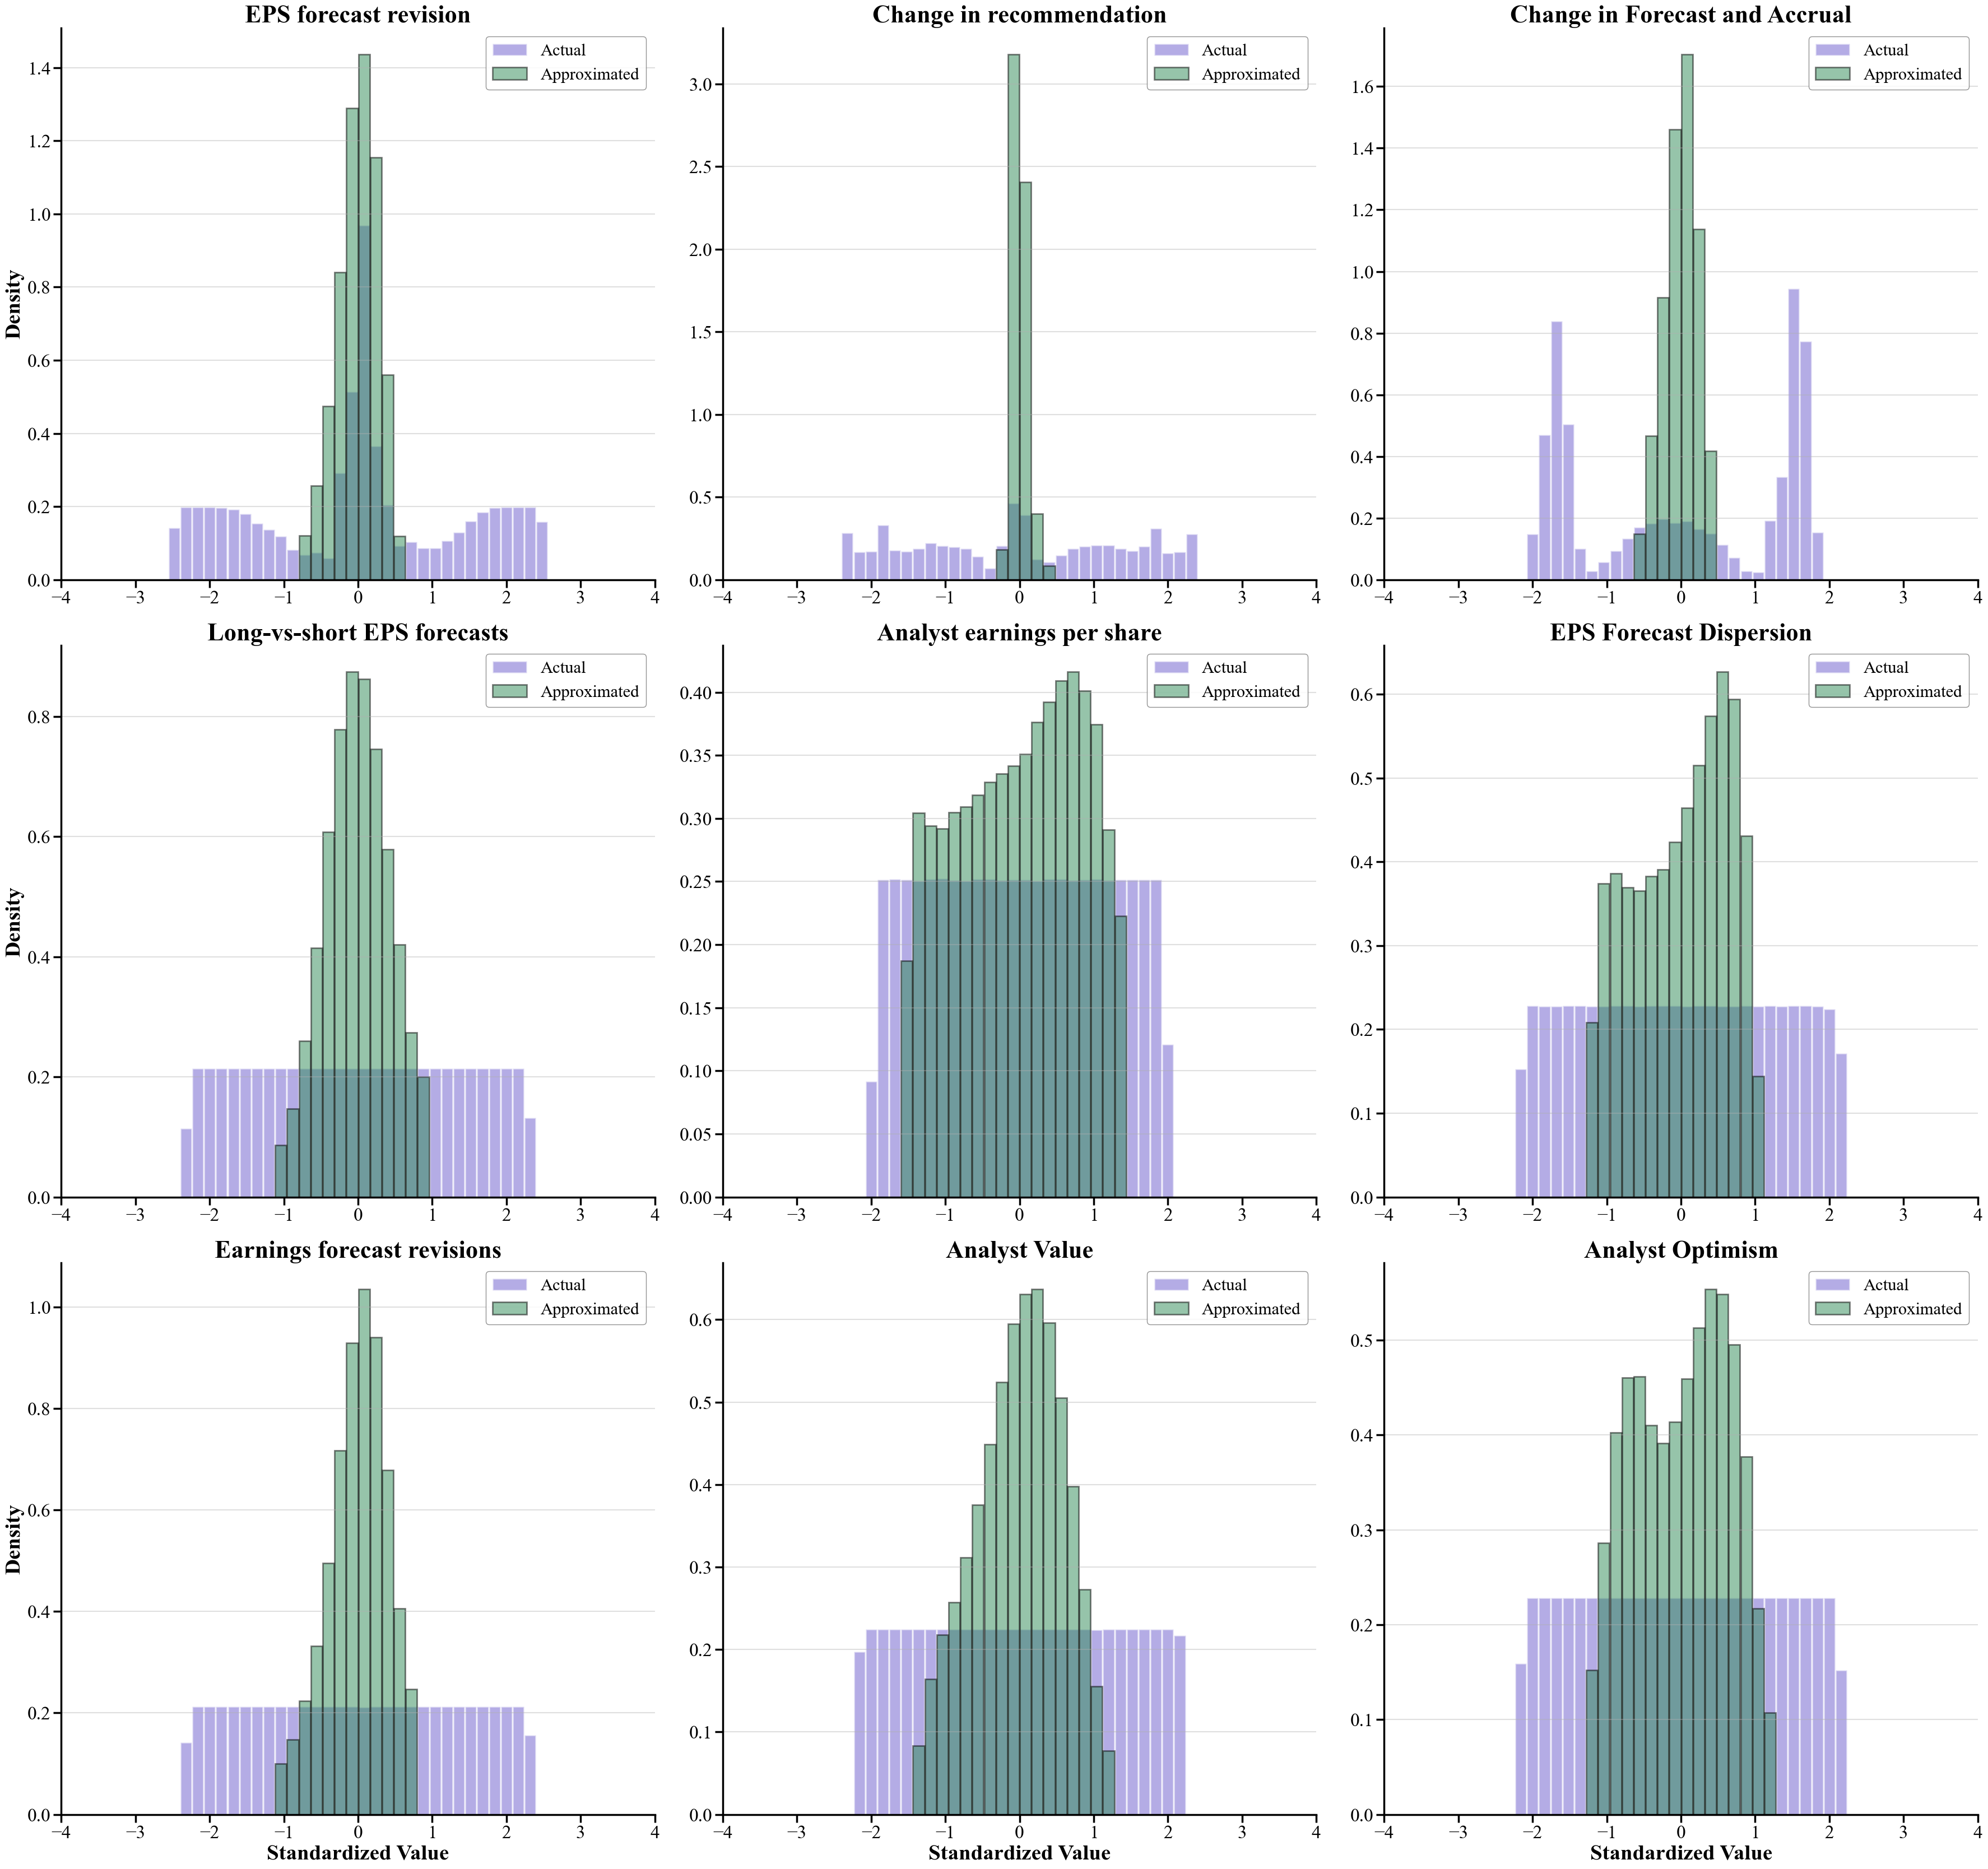

In [24]:
plot_X_distribution_comparison(horizon = '12month', embedding_method='autoencoder', weight_lambda = 1.0, bins = 50)